In [25]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras import datasets, layers, models

In [17]:
from tensorflow import keras

fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [18]:
train_images.shape, train_labels.shape, test_images.shape, test_labels.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [41]:
train_labels[:10] # 타켓이 정수 인덱스 따라서 sparse_categorical_crossentropy

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

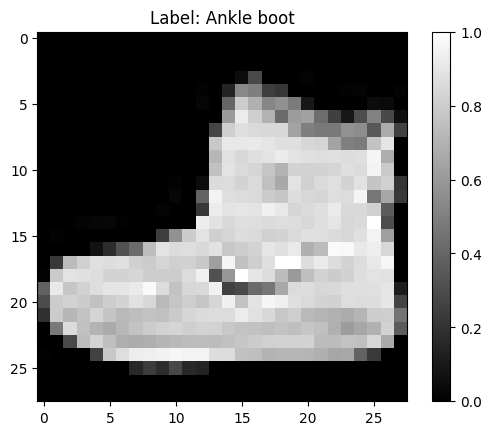

In [37]:
import matplotlib.pyplot as plt
from tensorflow import keras

# 클래스 이름 정의
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 첫 번째 이미지 시각화
plt.figure()
plt.imshow(train_images[0], cmap='gray')  # 흑백 이미지이므로 cmap='gray'
plt.title(f"Label: {class_names[train_labels[0]]}")
plt.colorbar()
plt.grid(False)
plt.show()

In [20]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [33]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),
    tf.keras.layers.Conv2D(16, 3, activation = 'relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation = 'relu'),
    tf.keras.layers.Dense(10, activation = 'softmax')
])

In [34]:
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape_3 (Reshape)         (None, 28, 28, 1)         0         
                                                                 
 conv2d_5 (Conv2D)           (None, 26, 26, 16)        160       
                                                                 
 flatten_3 (Flatten)         (None, 10816)             0         
                                                                 
 dense_6 (Dense)             (None, 128)               1384576   
                                                                 
 dense_7 (Dense)             (None, 10)                1290      
                                                                 
Total params: 1386026 (5.29 MB)
Trainable params: 1386026 (5.29 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [42]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=20, batch_size = 64)

Epoch 1/20
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0795 - accuracy: 0.9766
Epoch 2/20
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0498 - accuracy: 0.9840
Epoch 3/20
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0378 - accuracy: 0.9876
Epoch 4/20
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0317 - accuracy: 0.9893
Epoch 5/20
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0267 - accuracy: 0.9907
Epoch 6/20
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0208 - accuracy: 0.9930
Epoch 7/20
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0223 - accuracy: 0.9923
Epoch 8/20
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0190 - accuracy: 0.9933
Epoch 9/20
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0162 - accuracy: 0.9948
Epoch 10/20
1875/1875 [==============================] - 6s 3ms/step - loss: 0.014

In [43]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

print('test_loss : ', test_loss)
print('test_acc : ', test_acc)

313/313 [==============================] - 0s 1ms/step - loss: 0.8645 - accuracy: 0.8983
test_loss :  0.8644965887069702
test_acc :  0.8982999920845032


In [44]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=10, batch_size = 64)

Epoch 1/10
938/938 [==============================] - 4s 4ms/step - loss: 0.0048 - accuracy: 0.9984
Epoch 2/10
938/938 [==============================] - 4s 4ms/step - loss: 0.0024 - accuracy: 0.9994
Epoch 3/10
938/938 [==============================] - 3s 4ms/step - loss: 0.0041 - accuracy: 0.9987
Epoch 4/10
938/938 [==============================] - 4s 4ms/step - loss: 0.0030 - accuracy: 0.9991
Epoch 5/10
938/938 [==============================] - 4s 4ms/step - loss: 0.0034 - accuracy: 0.9990
Epoch 6/10
938/938 [==============================] - 3s 4ms/step - loss: 0.0047 - accuracy: 0.9985
Epoch 7/10
938/938 [==============================] - 3s 4ms/step - loss: 2.4387e-04 - accuracy: 1.0000
Epoch 8/10
938/938 [==============================] - 4s 4ms/step - loss: 5.6192e-05 - accuracy: 1.0000
Epoch 9/10
938/938 [==============================] - 4s 4ms/step - loss: 3.3838e-05 - accuracy: 1.0000
Epoch 10/10
938/938 [==============================] - 4s 4ms/step - loss: 2.4407e-05 - 

In [54]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

print('test_loss : ', test_loss)
print('test_acc : ', test_acc)

313/313 [==============================] - 1s 2ms/step - loss: 0.9676 - accuracy: 0.9097
test_loss :  0.9675707817077637
test_acc :  0.9096999764442444


In [55]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),
    tf.keras.layers.Conv2D(16, 3, activation = 'relu', padding='same'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation = 'relu'),
    tf.keras.layers.Dense(10, activation = 'softmax')
])

In [60]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.0359 - accuracy: 0.9874
Epoch 2/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0329 - accuracy: 0.9883
Epoch 3/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0328 - accuracy: 0.9887
Epoch 4/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0289 - accuracy: 0.9901
Epoch 5/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0268 - accuracy: 0.9910
Epoch 6/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.0231 - accuracy: 0.9922
Epoch 7/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0205 - accuracy: 0.9926
Epoch 8/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0227 - accuracy: 0.9925
Epoch 9/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0181 - accuracy: 0.9938
Epoch 10/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.017

In [61]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

print('test_loss : ', test_loss)
print('test_acc : ', test_acc)

313/313 [==============================] - 1s 1ms/step - loss: 0.7455 - accuracy: 0.9021
test_loss :  0.7454842925071716
test_acc :  0.9021000266075134


In [67]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),
    tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [68]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4115 - accuracy: 0.8539
Epoch 2/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.2779 - accuracy: 0.8999
Epoch 3/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.2327 - accuracy: 0.9140
Epoch 4/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.1986 - accuracy: 0.9267
Epoch 5/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.1729 - accuracy: 0.9359
Epoch 6/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.1491 - accuracy: 0.9447
Epoch 7/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.1295 - accuracy: 0.9526
Epoch 8/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.1130 - accuracy: 0.9589
Epoch 9/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0966 - accuracy: 0.9645
Epoch 10/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.085

In [69]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

print('test_loss : ', test_loss)
print('test_acc : ', test_acc)

313/313 [==============================] - 0s 1ms/step - loss: 0.2997 - accuracy: 0.9131
test_loss :  0.29965075850486755
test_acc :  0.913100004196167


In [70]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),
    tf.keras.layers.Conv2D(8, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [72]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
1875/1875 [==============================] - 5s 2ms/step - loss: 0.4709 - accuracy: 0.8309
Epoch 2/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.3201 - accuracy: 0.8840
Epoch 3/10
1875/1875 [==============================] - 5s 2ms/step - loss: 0.2773 - accuracy: 0.8979
Epoch 4/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.2481 - accuracy: 0.9090
Epoch 5/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.2269 - accuracy: 0.9171
Epoch 6/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.2089 - accuracy: 0.9218
Epoch 7/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.1916 - accuracy: 0.9292
Epoch 8/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.1779 - accuracy: 0.9335
Epoch 9/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.1628 - accuracy: 0.9390
Epoch 10/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.150

In [73]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

print('test_loss : ', test_loss)
print('test_acc : ', test_acc)

313/313 [==============================] - 0s 1ms/step - loss: 0.2640 - accuracy: 0.9097
test_loss :  0.26402559876441956
test_acc :  0.9096999764442444


In [74]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Reshape((28, 28, 1), input_shape=(28, 28)),
    tf.keras.layers.Conv2D(8, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [75]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
1875/1875 [==============================] - 5s 2ms/step - loss: 0.4613 - accuracy: 0.8340
Epoch 2/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.3095 - accuracy: 0.8876
Epoch 3/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.2646 - accuracy: 0.9025
Epoch 4/10
1875/1875 [==============================] - 5s 2ms/step - loss: 0.2381 - accuracy: 0.9124
Epoch 5/10
1875/1875 [==============================] - 5s 2ms/step - loss: 0.2163 - accuracy: 0.9204
Epoch 6/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.1989 - accuracy: 0.9258
Epoch 7/10
1875/1875 [==============================] - 5s 2ms/step - loss: 0.1847 - accuracy: 0.9316
Epoch 8/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.1708 - accuracy: 0.9356
Epoch 9/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.1562 - accuracy: 0.9420
Epoch 10/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.146

In [76]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

print('test_loss : ', test_loss)
print('test_acc : ', test_acc)

313/313 [==============================] - 1s 1ms/step - loss: 0.2666 - accuracy: 0.9122
test_loss :  0.2665711045265198
test_acc :  0.9121999740600586
